## Configurations for Colab

In [61]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !apt install python-opengl
    !apt install ffmpeg
    !apt install xvfb
    !pip install PyVirtualDisplay==3.0
    !pip install gymnasium==0.28.1
    from pyvirtualdisplay import Display
    
    # Start virtual display
    dis = Display(visible=0, size=(400, 400))
    dis.start()

# 01. DQN

[V. Mnih et al., "Human-level control through deep reinforcement learning." Nature, 518
(7540):529–533, 2015.](https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf)

Reinforcement learning is known to be unstable or even to diverge when a nonlinear function approximator such as a neural network is used to represent the action-value (also known as $Q$) function. This instability has several causes: the correlations present in the sequence of observations, the fact that small updates to $Q$ may significantly change the policy and therefore change the data distribution, and the correlations between the action-values ($Q$) and the target values $r + \gamma \max_{a'} Q(s', a')$.

The authors suggest two key ideas to address these instabilities with a novel variant of Q-learning: Replay buffer and Fixed Q-target.

#### Uniformly random sampling from Experience Replay Memory

Reinforcement learning agent stores the experiences consecutively in the buffer, so adjacent ($s, a, r, s'$) transitions stored are highly likely to have correlation. To remove this, the agent samples experiences uniformly at random from the pool of stored samples $\big( (s, a, r, s') \sim U(D) \big)$. See sample_batch method of ReplayBuffer class for more details.

#### Fixed Q-target

DQN uses an iterative update that adjusts the action-values ($Q$) towards target values that are only periodically updated, thereby reducing correlations with the target; if not, it is easily divergy because the target continuously moves. The Q-learning update at iteration $i$ uses the following loss function:

$$
L_i(\theta_i) = \mathbb{E}_{(s,a,r,s') \sim U(D)} \big[ \big( r + \gamma \max_{a'} Q(s',a';\theta_i^-) - Q(s, a; \theta_i) \big)^2 \big]
$$

in which $\gamma$ is the discount factor determining the agent’s horizon, $\theta_i$ are the parameters of the Q-network at iteration $i$ and $\theta_i^-$ are the network parameters used to compute the target at iteration $i$. The target network parameters $\theta_i^-$ are only updated with the Q-network parameters ($\theta_i$) every C steps and are held fixed between individual updates. ($C = 200$ in CartPole-v0)

#### For more stability: Gradient clipping

The authors also found it helpful to clip the error term from the update $r + \gamma \max_{a'} Q(s', a'; \theta_i^-) - Q(s,a,;\theta_i)$ to be between -1 and 1. Because the absolute value loss function $|x|$ has a derivative of -1 for all negative values of x and a derivative of 1 for all positive values of x, clipping the squared error to be between -1 and 1 corresponds to using an absolute value loss function for errors outside of the (-1,1) interval. This form of error clipping further improved the stability of the algorithm.

In [62]:
import os
from typing import Dict, List, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import clear_output

## Replay buffer

Typically, people implement replay buffers with one of the following three data structures:

  - collections.deque
  - list
  - numpy.ndarray
  
**deque** is very easy to handle once you initialize its maximum length (e.g. deque(maxlen=buffer_size)). However, the indexing operation of deque gets terribly slow as it grows up because it is [internally doubly linked list](https://wiki.python.org/moin/TimeComplexity#collections.deque). On the other hands, **list** is an array, so it is relatively faster than deque when you sample batches at every step. Its amortized cost of  *Get item* is [O(1)](https://wiki.python.org/moin/TimeComplexity#list).

Last but not least, let's see **numpy.ndarray**. numpy.ndarray is even faster than list due to the fact that it is [a homogeneous array of fixed-size items](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.html#numpy.ndarray), so you can get the benefits of [locality of reference](https://en.wikipedia.org/wiki/Locality_of_reference). Whereas list is an array of pointers to objects, even when all of them are of the same type.

Here, we are going to implement a replay buffer using numpy.ndarray.


Reference: [OpenAI spinning-up](https://github.com/openai/spinningup/blob/master/spinup/algos/sac/sac.py#L10)

In [63]:
class ReplayBuffer:
    """A simple numpy replay buffer."""

    def __init__(self, obs_dim: int, size: int, batch_size: int = 32):
        """
        Initializes the ReplayBuffer instance.

        Args:
            obs_dim (int): The dimension of the observation space. Determines the number of features 
                        in each observation stored in the buffer.
            size (int): The maximum number of transitions the buffer can store. This defines 
                        the capacity of the replay buffer.
            batch_size (int): The number of transitions to sample in a batch when calling 
                            `sample_batch`. Defaults to 32.
        """
        # Initialize buffers for storing transitions:
        self.obs_buf = np.zeros([size, obs_dim], dtype=np.float32)  # Buffer for current observations.
        self.next_obs_buf = np.zeros([size, obs_dim], dtype=np.float32)  # Buffer for next observations.
        self.acts_buf = np.zeros([size], dtype=np.float32)  # Buffer for actions taken.
        self.rews_buf = np.zeros([size], dtype=np.float32)  # Buffer for rewards received.
        self.done_buf = np.zeros(size, dtype=np.float32)  # Buffer for done flags (episode terminations).

        # Store the maximum buffer size and batch size for sampling.
        self.max_size, self.batch_size = size, batch_size

        # Initialize pointer (`ptr`) to track where to store the next transition.
        # Initialize current buffer size (`size`) to 0.
        self.ptr, self.size = 0, 0


    def store(self, obs: np.ndarray, act: np.ndarray, rew: float, next_obs: np.ndarray, done: bool):
        """
        Adds a new transition to the buffer.
        
        Args:
            obs: Current observation.
            act: Action taken.
            rew: Reward received.
            next_obs: Next observation after taking the action.
            done: Boolean indicating whether the episode has terminated.
        """
        # Store each element of the transition in the corresponding buffer.
        self.obs_buf[self.ptr] = obs
        self.next_obs_buf[self.ptr] = next_obs
        self.acts_buf[self.ptr] = act
        self.rews_buf[self.ptr] = rew
        self.done_buf[self.ptr] = done

        # Move the pointer to the next position in a circular fashion.
        self.ptr = (self.ptr + 1) % self.max_size

        # Increment the size of the buffer, ensuring it does not exceed `max_size`.
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self) -> Dict[str, np.ndarray]:
        """
        Samples a random batch of transitions from the buffer.

        Returns:
            A dictionary with keys ('obs', 'next_obs', 'acts', 'rews', 'done')
            and values as NumPy arrays of sampled transitions.
        """
        # Randomly sample `batch_size` unique indices from the stored transitions.
        idxs = np.random.choice(self.size, size=self.batch_size, replace=False)

        # Return the sampled transitions as a dictionary.
        return dict(
            obs=self.obs_buf[idxs],
            next_obs=self.next_obs_buf[idxs],
            acts=self.acts_buf[idxs],
            rews=self.rews_buf[idxs],
            done=self.done_buf[idxs]
        )

    def __len__(self) -> int:
        """
        Returns the current number of transitions stored in the buffer.

        This allows the use of `len()` on an instance of `ReplayBuffer`.
        """
        return self.size

## Network

We are going to use a simple network architecture with three fully connected layers and two non-linearity functions (ReLU).

In [64]:
class Network(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        """
        Initializes the neural network.

        Args:
            in_dim (int): The size of the input dimension. This represents the number of features 
                          in the input data.
            out_dim (int): The size of the output dimension. This represents the number of output
                           features (e.g., number of actions in reinforcement learning).
        """
        super(Network, self).__init__()  # Call the parent class constructor (nn.Module).

        # Define a sequential neural network with three fully connected layers:
        # - First layer maps from `in_dim` to 128 hidden units.
        # - Second layer maps from 128 hidden units to another 128 hidden units.
        # - Final layer maps from 128 hidden units to `out_dim`.
        # - ReLU activation is applied between each layer except the last one.
        self.layers = nn.Sequential(
            nn.Linear(in_dim, 128),  # Fully connected layer from `in_dim` to 128 units.
            nn.ReLU(),              # ReLU activation function.
            nn.Linear(128, 128),    # Fully connected layer from 128 to 128 units.
            nn.ReLU(),              # ReLU activation function.
            nn.Linear(128, out_dim) # Fully connected layer from 128 to `out_dim`.
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the network.

        Args:
            x (torch.Tensor): The input tensor, typically of shape (batch_size, in_dim).

        Returns:
            torch.Tensor: The output tensor, typically of shape (batch_size, out_dim).
        """
        return self.layers(x)  # Pass the input tensor through the network.

## DQN Agent

Here is a summary of DQNAgent class.

| Method           | Note                                                 |
| ---              | ---                                                  |
|select_action     | select an action from the input state.               |
|step              | take an action and return the response of the env.   |
|compute_dqn_loss  | return dqn loss.                                     |
|update_model      | update the model by gradient descent.                |
|target_hard_update| hard update from the local model to the target model.|
|train             | train the agent during num_frames.                   |
|test              | test the agent (1 episode).                          |
|plot              | plot the training progresses.                        |


In [65]:
class DQNAgent:
    """DQN Agent interacting with environment.
    
    Attribute:
        env (gym.Env): openAI Gym environment
        memory (ReplayBuffer): replay memory to store transitions
        batch_size (int): batch size for sampling
        epsilon (float): parameter for epsilon greedy policy
        epsilon_decay (float): step size to decrease epsilon
        max_epsilon (float): max value of epsilon
        min_epsilon (float): min value of epsilon
        target_update (int): period for target model's hard update
        gamma (float): discount factor
        dqn (Network): model to train and select actions
        dqn_target (Network): target model to update
        optimizer (torch.optim): optimizer for training dqn
        transition (list): transition information including 
                           state, action, reward, next_state, done
    """

    def __init__(
        self, 
        env: gym.Env,
        memory_size: int,
        batch_size: int,
        target_update: int,
        epsilon_decay: float,
        seed: int,
        max_epsilon: float = 1.0,
        min_epsilon: float = 0.1,
        gamma: float = 0.99,
    ):
        """
        Initializes the DQN Agent.

        Args:
            env (gym.Env): OpenAI Gym environment. Defines the environment in which the agent will interact.
            memory_size (int): Size of the memory buffer to store agent's experiences (state, action, reward, next_state).
            batch_size (int): Batch size for sampling random experiences from memory for training.
            target_update (int): Number of steps after which the target network is updated.
            epsilon_decay (float): Decay rate for epsilon in the epsilon-greedy strategy. Used for exploration.
            seed (int): Seed value for random number generators for reproducibility.
            max_epsilon (float): Maximum value for epsilon (exploration factor).
            min_epsilon (float): Minimum value for epsilon. Prevents it from reaching 0.
            gamma (float): Discount factor for future rewards in the Bellman equation.

        Attributes:
            device (torch.device): The device on which to run the model (e.g., CPU, GPU, MPS).
            dqn (Network): The main Q-network for predicting Q-values.
            dqn_target (Network): The target Q-network used for stable learning.
            optimizer (torch.optim): Optimizer for training the Q-network.
            transition (list): Stores the current transition (state, action, reward, next_state, done).
            is_test (bool): Flag to indicate whether the agent is in test mode or training mode.
        """
        # Get the dimensions of the observation and action space from the environment
        obs_dim = env.observation_space.shape[0]
        action_dim = env.action_space.n
        
        # Store the environment and configuration parameters
        self.env = env
        self.memory = ReplayBuffer(obs_dim, memory_size, batch_size)  # ReplayBuffer stores agent's experience
        self.batch_size = batch_size
        self.epsilon = max_epsilon  # Starting epsilon for exploration
        self.epsilon_decay = epsilon_decay  # Epsilon decay factor
        self.seed = seed  # Seed for reproducibility
        self.max_epsilon = max_epsilon  # Maximum exploration value for epsilon
        self.min_epsilon = min_epsilon  # Minimum exploration value for epsilon
        self.target_update = target_update  # How often to update the target network
        self.gamma = gamma  # Discount factor for future rewards

        # Set the device for model computation (CPU, GPU, or MPS)
        self.device = torch.device(
            "mps" if torch.backends.mps.is_available() else  # Check for Apple’s MPS (Metal Performance Shaders)
            "cuda" if torch.cuda.is_available() else  # Check if CUDA-enabled GPU is available
            "cpu"  # Default to CPU if neither MPS nor CUDA are available
        )
        print(self.device)

        # Initialize the DQN and target networks with the appropriate dimensions
        self.dqn = Network(obs_dim, action_dim).to(self.device)  # Main Q-network
        self.dqn_target = Network(obs_dim, action_dim).to(self.device)  # Target Q-network

        # Copy the weights of the dqn to dqn_target (the target is initially the same as the main Q-network)
        self.dqn_target.load_state_dict(self.dqn.state_dict())
        self.dqn_target.eval()  # Set the target network to evaluation mode (no gradient computation)

        # Initialize the optimizer for the DQN with Adam optimizer
        self.optimizer = optim.Adam(self.dqn.parameters())  # Adam is used for training the model

        # Initialize transition (this stores the current state, action, reward, next_state, done tuple)
        self.transition = list()

        # Set the mode to training, indicating that the agent is not in test mode
        self.is_test = False

    def select_action(self, state: np.ndarray) -> np.ndarray:
        """Select an action from the input state."""
        # epsilon-greedy policy: with probability epsilon, choose a random action
        # otherwise, choose the action that maximizes the Q-value estimated by the DQN
        if self.epsilon > np.random.random():
            # Select a random action from the action space of the environment
            selected_action = self.env.action_space.sample()
        else:
            # Use the trained DQN to estimate the Q-values for the given state
            # Convert the input state to a torch tensor, move to the appropriate device (GPU/CPU)
            # and pass it through the DQN to get the action with the highest Q-value
            selected_action = self.dqn(
                torch.FloatTensor(state).to(self.device)
            ).argmax()  # argmax selects the action with the maximum Q-value
            
            # Detach the action from the computation graph and convert it back to a numpy array
            selected_action = selected_action.detach().cpu().numpy()
        
        # If it's not in test mode, store the state-action pair as a transition
        if not self.is_test:
            self.transition = [state, selected_action]
        
        # Return the selected action
        return selected_action


    def step(self, action: np.ndarray) -> Tuple[np.ndarray, np.float64, bool]:
        """Take an action and return the response of the env."""
        # The agent takes the provided action in the environment.
        # The environment returns the next state, the reward, and whether the episode has ended (terminated or truncated).
        next_state, reward, terminated, truncated, _ = self.env.step(action)
        
        # 'done' is a boolean that indicates whether the episode has finished.
        # This is set to True if either 'terminated' or 'truncated' is True.
        done = terminated or truncated

        # If the agent is not in test mode, save the transition to the agent's memory.
        # A transition includes the current state, the action taken, the reward received,
        # the next state, and whether the episode ended ('done').
        if not self.is_test:
            self.transition += [reward, next_state, done]
            self.memory.store(*self.transition)

        # Return the next state, reward, and done flag.
        return next_state, reward, done


    def update_model(self) -> torch.Tensor:
        """Update the model by gradient descent."""
        # Sample a batch of experiences from the agent's memory (experience replay).
        samples = self.memory.sample_batch()

        # Compute the loss for the DQN model based on the sampled experiences.
        # This typically involves computing the difference between the predicted Q-values
        # and the target Q-values for the sampled states and actions.
        loss = self._compute_dqn_loss(samples)

        # Zero the gradients in the optimizer to prepare for a new backpropagation.
        self.optimizer.zero_grad()

        # Perform backpropagation to calculate the gradients of the loss with respect to the model parameters.
        loss.backward()

        # Update the model parameters using the optimizer and the computed gradients.
        self.optimizer.step()

        # Return the scalar loss value as a tensor, which can be used for monitoring and debugging.
        return loss.item()

        
    def train(self, num_frames: int, plotting_interval: int = 200):
        """Train the agent."""
        self.is_test = False  # Set the agent to training mode
        
        # Initialize the environment and state
        state, _ = self.env.reset(seed=self.seed)
        update_cnt = 0  # Initialize the update counter for target network updates
        epsilons = []  # List to store epsilon values for plotting
        losses = []  # List to store loss values for plotting
        scores = []  # List to store scores (total reward per episode) for plotting
        score = 0  # Initialize the score for the current episode

        # Loop through each frame (time step) for the training process
        for frame_idx in range(1, num_frames + 1):
            # Select an action based on the current state (using epsilon-greedy policy)
            action = self.select_action(state)
            
            # Take the selected action, get the next state, reward, and done flag
            next_state, reward, done = self.step(action)

            # Update the state for the next iteration
            state = next_state
            
            # Accumulate the reward for the current episode
            score += reward

            # If the episode ends (done flag is True), reset the environment
            if done:
                state, _ = self.env.reset(seed=self.seed)  # Reset the environment to start a new episode
                scores.append(score)  # Store the score for the episode
                score = 0  # Reset the score for the next episode

            # If enough experiences are available in memory (batch size is reached), perform a model update
            if len(self.memory) >= self.batch_size:
                loss = self.update_model()  # Update the model and get the loss
                losses.append(loss)  # Store the loss
                update_cnt += 1  # Increment the update counter
                
                # Linearly decrease epsilon over time to reduce exploration
                self.epsilon = max(
                    self.min_epsilon,  # Lower bound for epsilon
                    self.epsilon - (
                        self.max_epsilon - self.min_epsilon  # Decrease from max epsilon to min epsilon
                    ) * self.epsilon_decay  # Decay factor
                )
                epsilons.append(self.epsilon)  # Store the epsilon value for plotting
                
                # If the target network needs to be updated, perform a hard update
                if update_cnt % self.target_update == 0:
                    self._target_hard_update()

            # If the current frame index is a multiple of the plotting interval, plot the training progress
            if frame_idx % plotting_interval == 0:
                self._plot(frame_idx, scores, losses, epsilons)
                
        # Close the environment after training
        self.env.close()
            
    def test(self, video_folder: str) -> None:
        """Test the agent."""
        self.is_test = True  # Set the agent to test mode (disables exploration)

        # Set up video recording by wrapping the environment with a video recorder.
        # The agent's interaction with the environment will be recorded in the specified folder.
        naive_env = self.env  # Save the original environment (in case we need to restore it later)
        self.env = gym.wrappers.RecordVideo(self.env, video_folder=video_folder)  # Wrap the environment to record video

        # Reset the environment to start a new episode
        state, _ = self.env.reset(seed=self.seed)
        done = False  # Initialize the done flag (episode finished or not)
        score = 0  # Initialize the score to keep track of the total reward in the episode

        # Run the test loop until the episode ends (done flag is True)
        while not done:
            # Select the best action based on the current state (using the trained model)
            action = self.select_action(state)
            
            # Take the selected action and get the next state, reward, and done flag
            next_state, reward, done = self.step(action)

            # Update the state for the next iteration
            state = next_state
            
            # Accumulate the reward for the current episode
            score += reward

        # Print the final score (total reward accumulated during the episode)
        print("score: ", score)
        
        # Close the environment after testing
        self.env.close()

        # Restore the original environment (removes video recording wrapper)
        self.env = naive_env


    def _compute_dqn_loss(self, samples: Dict[str, np.ndarray]) -> torch.Tensor:
        """Return DQN loss."""
        device = self.device  # Get the device (e.g., CPU or GPU) to move the tensors
        # Convert the numpy arrays in 'samples' to PyTorch tensors and move them to the appropriate device
        state = torch.FloatTensor(samples["obs"]).to(device)
        next_state = torch.FloatTensor(samples["next_obs"]).to(device)
        action = torch.LongTensor(samples["acts"].reshape(-1, 1)).to(device)
        reward = torch.FloatTensor(samples["rews"].reshape(-1, 1)).to(device)
        done = torch.FloatTensor(samples["done"].reshape(-1, 1)).to(device)

        # Compute the current Q-value (Q(s_t, a_t)) from the current state and selected action
        curr_q_value = self.dqn(state).gather(1, action)
        
        # Compute the target Q-value using the next state and the target Q-network
        # The target is the maximum Q-value predicted for the next state (using target network)
        next_q_value = self.dqn_target(next_state).max(dim=1, keepdim=True)[0].detach()

        # Create a mask to handle terminal states where the next Q-value doesn't apply
        # For terminal states, the target is just the reward (no future value)
        mask = 1 - done  # Mask for non-terminal states

        # Compute the target Q-value using the reward and the next Q-value
        target = (reward + self.gamma * next_q_value * mask).to(self.device)

        # Calculate the loss between the predicted Q-value and the target Q-value using Smooth L1 loss
        loss = F.smooth_l1_loss(curr_q_value, target)

        return loss


    def _target_hard_update(self):
        """Hard update: target <- local."""
        self.dqn_target.load_state_dict(self.dqn.state_dict())
                
    def _plot(
        self, 
        frame_idx: int, 
        scores: List[float], 
        losses: List[float], 
        epsilons: List[float],
    ):
        """Plot the training progresses."""
        # Clears the previous output (for cleaner updates in a Jupyter notebook environment)
        clear_output(True)
        
        # Create a new figure with a size of 20x5 inches
        plt.figure(figsize=(20, 5))
        
        # Plot the scores on the left subplot (subplot 131)
        # This plot shows the training performance (score) at each frame
        plt.subplot(131)
        plt.title('frame %s. score: %s' % (frame_idx, np.mean(scores[-10:])))
        plt.plot(scores)  # Plot all the scores
        
        # Plot the loss on the middle subplot (subplot 132)
        # This plot shows the loss curve during training
        plt.subplot(132)
        plt.title('loss')
        plt.plot(losses)  # Plot all the losses
        
        # Plot the epsilon values on the right subplot (subplot 133)
        # This plot shows the epsilon value (exploration rate) during training
        plt.subplot(133)
        plt.title('epsilons')
        plt.plot(epsilons)  # Plot all epsilon values
        
        # Show the plots
        plt.show()


## Environment

You can see the [code](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/cartpole.py) and [configurations](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/cartpole.py#L91) of CartPole-v1 from Farama Gymnasium's repository.

In [66]:
# environment
env = gym.make("CartPole-v1", max_episode_steps=500, render_mode="rgb_array")

## Set random seed

In [67]:
seed = 777

def seed_torch(seed):
    torch.manual_seed(seed)
    if torch.backends.cudnn.enabled:
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

np.random.seed(seed)
seed_torch(seed)

## Initialize

In [68]:
# parameters
num_frames = 100000
memory_size = 1000
batch_size = 64
target_update = 100
epsilon_decay = 1 / 2000

agent = DQNAgent(env, memory_size, batch_size, target_update, epsilon_decay, seed)

mps


## Train

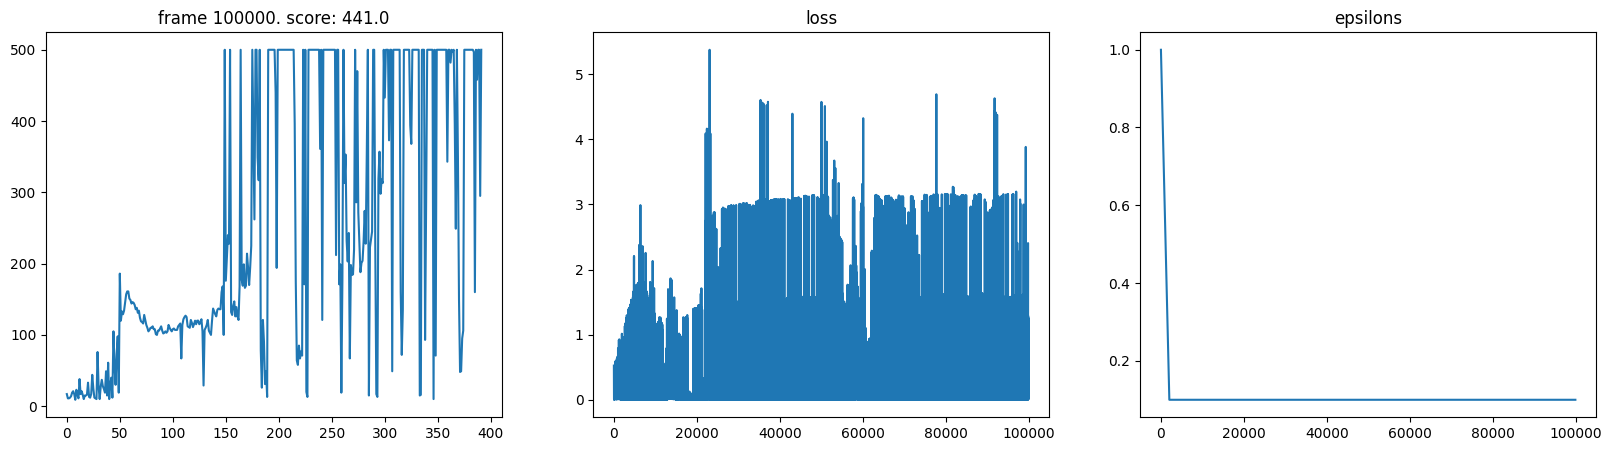

In [69]:
agent.train(num_frames)

## Test

Run the trained agent (1 episode).

In [70]:
video_folder="videos/dqn"
agent.test(video_folder=video_folder)

/opt/homebrew/Caskroom/miniconda/base/envs/pytorch_env/lib/python3.8/site-packages/gymnasium/wrappers/record_video.py:94: UserWarning: WARN: Overwriting existing videos at /Users/vishalsankarram/Desktop/github/rainbow-is-all-you-need/videos/dqn folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/pytorch_env/lib/python3.8/site-packages/gymnasium/core.py:297: UserWarning: WARN: env.is_vector_env to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.is_vector_env` for environment variables or `env.get_attr('is_vector_env')` that will search the reminding wrappers.
  logger.warn(


Moviepy - Building video /Users/vishalsankarram/Desktop/github/rainbow-is-all-you-need/videos/dqn/rl-video-episode-0.mp4.
Moviepy - Writing video /Users/vishalsankarram/Desktop/github/rainbow-is-all-you-need/videos/dqn/rl-video-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /Users/vishalsankarram/Desktop/github/rainbow-is-all-you-need/videos/dqn/rl-video-episode-0.mp4
score:  500.0


## Render

In [71]:
import base64
import glob
import io
import os

from IPython.display import HTML, display


def ipython_show_video(path: str) -> None:
    """Show a video at `path` within IPython Notebook."""
    if not os.path.isfile(path):
        raise NameError("Cannot access: {}".format(path))

    video = io.open(path, "r+b").read()
    encoded = base64.b64encode(video)

    display(HTML(
        data="""
        <video width="320" height="240" alt="test" controls>
        <source src="data:video/mp4;base64,{0}" type="video/mp4"/>
        </video>
        """.format(encoded.decode("ascii"))
    ))


def show_latest_video(video_folder: str) -> str:
    """Show the most recently recorded video from video folder."""
    list_of_files = glob.glob(os.path.join(video_folder, "*.mp4"))
    latest_file = max(list_of_files, key=os.path.getctime)
    ipython_show_video(latest_file)
    return latest_file


latest_file = show_latest_video(video_folder=video_folder)
print("Played:", latest_file)

Played: videos/dqn/rl-video-episode-0.mp4
